# Minimal code on real data

In [18]:
import pandas as pd
import numpy as np

In [19]:
file_path = "../data/processed/eurusd_dukascopy_bid_201901.parquet"
df = pd.read_parquet(file_path)
df['datetime'] = pd.to_datetime(df['datetime'])
df = df[df['price_type'] == 'BID'].copy()
df.set_index('datetime', inplace=True)
df.sort_index(inplace=True)

print("--- Raw Tick Stats ---")
print(df['price'].describe())
print(f"Total Ticks: {len(df)}")

tick_window = 100
df_bars = df.iloc[::tick_window].copy()

df_bars['log_returns'] = np.log(df_bars['price'] / df_bars['price'].shift(1))
df_bars.dropna(inplace=True)

print("\n--- 1000-Tick Bar Return Stats ---")
print(df_bars['log_returns'].describe())

--- Raw Tick Stats ---
count    3.477166e+06
mean     1.142110e+00
std      5.633418e-03
min      1.128920e+00
25%      1.137860e+00
50%      1.141340e+00
75%      1.146060e+00
max      1.156970e+00
Name: price, dtype: float64
Total Ticks: 3477166

--- 1000-Tick Bar Return Stats ---
count    3.477100e+04
mean    -3.113598e-08
std      1.106659e-04
min     -2.238561e-03
25%     -6.118400e-05
50%      0.000000e+00
75%      6.128122e-05
max      1.836628e-03
Name: log_returns, dtype: float64


### Markov switching

In [20]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

model = sm.tsa.MarkovRegression(
    endog=df_bars['log_returns'],
    k_regimes=2, 
    trend='c',
    switching_trend=False,
    switching_variance=True
)

result = model.fit()
print(result.summary())

df_bars['prob_state_1'] = result.smoothed_marginal_probabilities[1]
print(df_bars)

c:\Users\ofurn\Dokumenter\Github\stk-mat2011\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                        Markov Switching Model Results                        
Dep. Variable:            log_returns   No. Observations:                34771
Model:               MarkovRegression   Log Likelihood              270138.657
Date:                Fri, 17 Apr 2026   AIC                        -540267.314
Time:                        18:30:32   BIC                        -540225.032
Sample:                             0   HQIC                       -540253.842
                              - 34771                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      7.225e-09   1.34e-06      0.005      0.996   -2.61e-06    2.63e-06
                             Regime 1 parameters    

### Plot

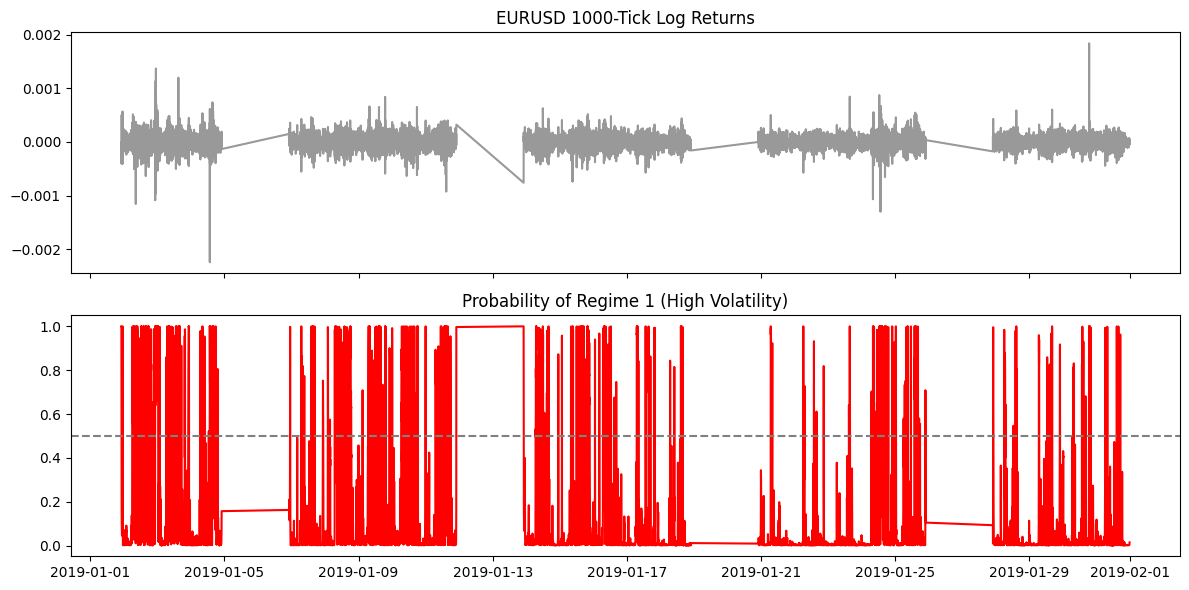

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=True)

axes[0].plot(df_bars.index, df_bars['log_returns'], color='black', alpha=0.4)
axes[0].set_title('EURUSD 1000-Tick Log Returns')

axes[1].plot(df_bars.index, df_bars['prob_state_1'], color='red')
axes[1].set_title('Probability of Regime 1 (High Volatility)')
axes[1].axhline(0.5, color='gray', linestyle='--') # 50% threshold

plt.tight_layout()
plt.show()